<a href="https://colab.research.google.com/github/samiha-mahin/Covid-19/blob/main/covid19_Feature_Extraction%26Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Covid Dataset.csv")

In [ ]:
df.head()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,...,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Yes
1,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,...,Yes,No,No,No,Yes,Yes,No,No,No,Yes
2,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,Yes,No,No,No,No,No,No,Yes
3,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Yes,...,No,No,Yes,No,Yes,Yes,No,No,No,Yes
4,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,...,No,Yes,No,Yes,No,Yes,No,No,No,Yes


In [ ]:
df.shape

(5434, 21)

In [ ]:
df.describe()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
count,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434,...,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,1,1,2
top,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,No,...,Yes,No,No,Yes,No,Yes,No,No,No,Yes
freq,3620,4273,4307,3953,2952,2920,2869,2736,2911,2846,...,2821,2883,2983,2726,2924,2820,3172,5434,5434,4383


In [ ]:
df.describe()

,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
count,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434,...,5434,5434,5434,5434,5434,5434,5434,5434,5434,5434
unique,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,1,1,2
top,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,No,...,Yes,No,No,Yes,No,Yes,No,No,No,Yes
freq,3620,4273,4307,3953,2952,2920,2869,2736,2911,2846,...,2821,2883,2983,2726,2924,2820,3172,5434,5434,4383


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5434 entries, 0 to 5433
Data columns (total 21 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Breathing Problem                        5434 non-null   object
 1   Fever                                    5434 non-null   object
 2   Dry Cough                                5434 non-null   object
 3   Sore throat                              5434 non-null   object
 4   Running Nose                             5434 non-null   object
 5   Asthma                                   5434 non-null   object
 6   Chronic Lung Disease                     5434 non-null   object
 7   Headache                                 5434 non-null   object
 8   Heart Disease                            5434 non-null   object
 9   Diabetes                                 5434 non-null   object
 10  Hyper Tension                            5434 non-null   obj

In [ ]:
df.isnull().sum()

,0
Breathing Problem,0
Fever,0
Dry Cough,0
Sore throat,0
Running Nose,0
Asthma,0
Chronic Lung Disease,0
Headache,0
Heart Disease,0
Diabetes,0


In [10]:
print(df['COVID-19'].value_counts())

COVID-19
Yes    4383
No     1051
Name: count, dtype: int64


# **Feature Extraction**

## **Chi-Square**

In [15]:
import pandas as pd
import numpy as np

# Assuming your dataframe is called df
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

                                    Feature  Chi2 Score        p-value
13                            Abroad travel  587.725530  7.827798e-130
15                 Attended Large Gathering  445.070586   8.529145e-99
3                               Sore throat  374.479605   1.980893e-83
0                         Breathing Problem  357.224357   1.132345e-79
14               Contact with COVID Patient  345.368317   4.322879e-77
2                                 Dry Cough  242.944097   8.969679e-55
1                                     Fever  144.581349   2.651486e-33
17  Family working in Public Exposed Places   81.414100   1.830473e-19
16            Visited Public Exposed Places   37.487883   9.198266e-10
10                            Hyper Tension   29.155431   6.679823e-08
5                                    Asthma   23.614977   1.176681e-06
6                      Chronic Lung Disease    9.268135   2.331750e-03
11                                 Fatigue     5.102075   2.389724e-02
9     

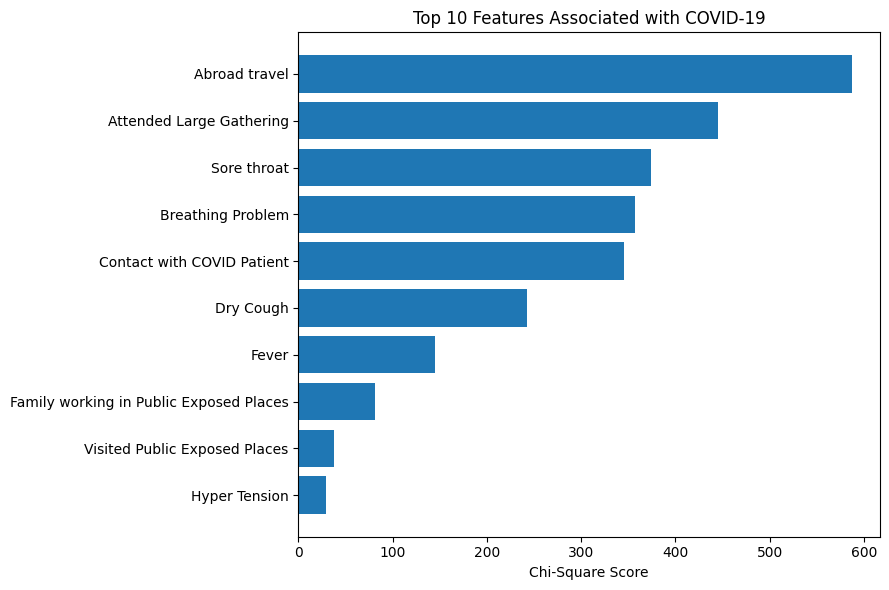

In [21]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2

df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})

# -------------------------------
#  Split features and target
# -------------------------------
X = df_encoded.drop(columns=['COVID-19'])
y = df_encoded['COVID-19']

# -------------------------------
#  Apply Chi-Square test
# -------------------------------
chi_scores, chi_pvalues = chi2(X, y)

chi2_results = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores,
    'p-value': chi_pvalues
})

# -------------------------------
#  Sort by Chi-Square score
# -------------------------------
chi2_results = chi2_results.sort_values(by='Chi2 Score', ascending=False)

print(chi2_results)

# -------------------------------
#  Top 10 significant features
# -------------------------------
top_features = chi2_results.head(10)

# -------------------------------
#  Visualization
# -------------------------------
plt.figure(figsize=(9, 6))
plt.barh(top_features['Feature'][::-1], top_features['Chi2 Score'][::-1])
plt.xlabel('Chi-Square Score')
plt.title('Top 10 Features Associated with COVID-19')
plt.tight_layout()
plt.show()


In [22]:
# Select statistically significant features
important_features = chi2_results[
    (chi2_results['p-value'] < 0.05) &
    (chi2_results['Chi2 Score'].notna())
]['Feature'].tolist()

print("Important Features:")
print(important_features)


Important Features:
['Abroad travel', 'Attended Large Gathering', 'Sore throat', 'Breathing Problem', 'Contact with COVID Patient', 'Dry Cough', 'Fever', 'Family working in Public Exposed Places', 'Visited Public Exposed Places', 'Hyper Tension', 'Asthma', 'Chronic Lung Disease', 'Fatigue ', 'Diabetes']


In [23]:
X_selected = df_encoded[important_features]
y = df_encoded['COVID-19']

print("Shape of selected feature set:", X_selected.shape)


Shape of selected feature set: (5434, 14)
